<a href="https://colab.research.google.com/github/ratatatan/itmo-oomd/blob/prac2/%D0%9A%D1%83%D1%80%D1%81_%D0%BD%D0%B0_Stepik_3_%D0%A2%D0%BE%D0%BB%D0%BA%D0%B0%D1%87%D0%B5%D0%B2_%D0%A2.%D0%A1._K3161.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Сделайте копию колаба (файл => создать копию на диске). Переименуйте, добавив в название ФИО и номер группы


# Модуль 3. Коррекция яркости и цвета

В документе есть ссылки на короткие видео с пояснениями и задания. В принципе задания можно попробовать выполнить на Степике, но при этом обязательно все решения и результаты тестов нужно поместить в этом колабе. Решения нужно помещать сразу после соответствующего задания.

## 3.1 Линейная коррекция контраста



Видео урока: https://stepik.org/lesson/58402/step/1

Для выполнения заданий вам понадобится считать и визуализировать гистограмму изображения. Пример работы с функциями, позволяющими это сделать в python, можно посмотреть в [ноутбуке](https://nbviewer.org/urls/stepik.org/media/attachments/lesson/58402/hist.ipynb).

**Задание 1. Автоконтраст черно-белого изображения**

Прочитайте изображение из файла img.png. Примените к нему линейное выравнивание яркости: примените к каждому пикселю функцию

$f(x) = (x - x_{min}) \frac{255}{(x_{max}-x_{min})}$

После вычисления функции значения изображения окажутся вещественными. Чтобы привести их к целым числам, используйте метод img.astype('uint8'), который возвращает изображение в целых числах. Результат сохраните в файл out_img.png.
В примере входа и выхода указаны ссылки на файлы. Скачав эти файлы, можно протестировать свою программу.

*Sample Input:*

https://stepik.org/media/attachments/lesson/58402/tiger-low-contrast.png


*Sample Output:*

https://stepik.org/media/attachments/lesson/58402/tiger-high-contrast.png

Видео урока: https://stepik.org/lesson/58402/step/4

In [1]:
! wget -O img.png -q https://stepik.org/media/attachments/lesson/58402/tiger-low-contrast.png

In [14]:
import numpy as np
from skimage.io import imread, imsave, imshow


def get_hist(image):
  return np.histogram(image, bins=range(257))[0]


def autocontrast(image):
  min_x, max_x = np.min(img), np.max(img)
  return ((image - min_x)*(255/(max_x - min_x))) \
    .astype(np.uint8)


img = imread("img.png")
print(get_hist(img))

ac_img = autocontrast(img)
print(get_hist(ac_img))

imsave("out_img.png", ac_img)

[    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0 22696  6314  7991  5615
  9597  7092  9280  5586  8463  5853  8044  4791  6567  4235  5755  3528
  4430  2667  3941  3825  2790  3047  5116  4173  8553  7480 14273  8817
 10857  6565  9880  6857 11231  7980 11412  7716 11

**Задание 2. Количество столбцов**

Подсчет минимума и максимума устойчивого автоконтраста

Прочитайте изображение из файла img.png. Подсчитайте минимум и максимум яркости для стабильного автоконтраста этого изображения. Необходимо отбросить 5% самых светлых и 5% самых темных пикселей. Для получения числа отбрасываемых пикселей используйте формулу

$ k = round (\#pix*0.05)$

Два посчитанных числа (минимум и максимум) выведите на стандартный вывод через пробел.

Попробуйте подсчитать минимум и максимум для стабильного автоконтраста двумя способами, указанными в видео.

В примере входа указана ссылка на файлы. Скачав этот файл, можно протестировать свою программу.

*Sample Input:*

https://stepik.org/media/attachments/lesson/58402/tiger-low-contrast.png

*Sample Output:*

129 208

In [15]:
! wget -O img.png -q https://stepik.org/media/attachments/lesson/58402/tiger-low-contrast.png

In [33]:
img = imread("img.png")

k = round(len(img)*0.05)

# ПЕРВЫЙ СПОСОБ
sorted_img = np.sort(img.flatten())
min_x, max_x = sorted_img[k], sorted_img[-k-1]
print(min_x, max_x)

# ВТОРОЙ СПОСОБ
h = get_hist(img)

min_x = 0
counter = 0
for i in range(256):
  counter += h[i]
  if counter > k:
    min_x = i
    break

max_x = 0
counter = 0
for i in range(255, 0, -1):
  counter += h[i]
  if counter > k:
    max_x = i
    break


print(min_x, max_x)

128 230
128 230


**Задание 3. Устойчивый автоконтраст черно-белого изображения**

Прочитайте изображение из файла img.png. Примените к нему линейное выравнивание яркости: примените к каждому пикселю функцию

Для вычисления максимума и минимума отбрасывайте по 5% самых светлых и самых темных пикселей (как в предыдущем задании). Перед вычислениями приведите изображение в вещественные числа (img.astype('float')), иначе может возникнуть переполнение (т.к. значения некоторых пикселей мы игнорируем при подсчете минимума и максимума). После растяжения яркости обрежьте значения изображения от 0 до 255 с помощью функции numpy.clip.

После вычисления функции значения изображения окажутся вещественными. Чтобы привести их к целым числам, используйте метод img.astype('uint8'), который возвращает изображение в целых числах. Результат сохраните в файл out_img.png.

В примере входа и выхода указаны ссылки на файлы. Скачав эти файлы, можно протестировать свою программу. Для сравнения вашего ответа с верным используйте функцию numpy.array_equal.

*Sample Input:*

https://stepik.org/media/attachments/lesson/58402/tiger-low-contrast.png

*Sample Output:*

https://stepik.org/media/attachments/lesson/58402/tiger-stable-contrast.png

In [17]:
! wget -O img.png -q https://stepik.org/media/attachments/lesson/58402/tiger-low-contrast.png

<ipython-input-38-abba61be537b>:14: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(ac_img)


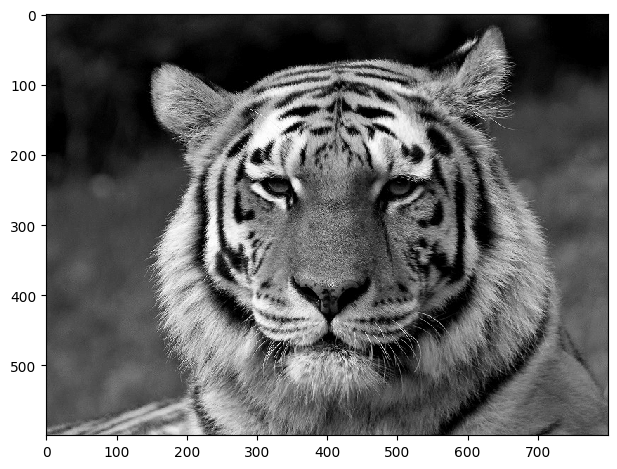

In [38]:
def autocontrast(image, min_x, max_x):
  return np.clip((image - min_x)*(255/(max_x - min_x)),
                 0, 255) \
    .astype(np.uint8)


img = imread("img.png").astype(np.float16)

k = round(len(img)*0.05)
sorted_img = np.sort(img.flatten())
min_x, max_x = sorted_img[k], sorted_img[-k-1]

ac_img = autocontrast(img, min_x, max_x)
imshow(ac_img)

## 3.2 Коррекция контраста цветного изображения

Видео урока: https://stepik.org/lesson/60609/step/1

**Задание 1. Устойчивый цветной автоконтраст**

Прочитайте цветное изображение из файла img.png. Примените к нему устойчивый автоконтраст. Для этого:
1. Переведите изображение в вещественные числа от 0 до 1.
2. Переведите изображение в пространство YUV по формулам:

$Y =  0.2126⋅R+0.7152⋅G+0.0722⋅B$

$U = -0.0999⋅R - 0.3360⋅G+0.4360⋅B$

$V=  0.6150⋅R - 0.5586⋅G - 0.0563⋅B$

3. Найдите максимум и минимум для устойчивого автоконтраста с отбрасыванием 5% самых светлых и 5% самых темных пикселей.
4. Примените линейное растяжение канала Y по формуле
5. Обрежьте значения канала Y от 0 до 1.
6. Переведите изображение в пространство RGB по формулам:

$ R =Y+1.2803⋅V$

$ G=Y-0.2148⋅U-0.3805⋅V$

$B=Y+2.1279⋅U$

7. Обрежьте значения изображения от 0 до 1.
8. Переведите изображение в целые числа от 0 до 255.

Результат сохраните в файл out_img.png.

В примере входа и выхода указаны ссылки на файлы. Скачав эти файлы, можно протестировать свою программу.

*Sample Input:*

https://stepik.org/media/attachments/lesson/60609/tiger-color.png

*Sample Output:*

https://stepik.org/media/attachments/lesson/60609/tiger-stable-contrast.png

## 3.3 Баланс белого. Модель «серого мира»

Видео урока: https://stepik.org/lesson/60610/step/1

**Задание 1. Преобразование серого мира**

Прочитайте изображение из файла img.png. Примените к нему преобразование серого мира. Для этого:
1. Сконвертируйте изображение в вещественные числа.
2. Подсчитайте коэффициенты $r_w, g_w, b_w$ как описано в видео.
3. Поделите каналы изображения на коэффициенты.
4. Обрежьте значения пикселей, чтобы они не выходили из допустимого диапазона ($[0; 255]$ или $[0;1]$).
Результат сохраните в файл out_img.png.

В примере входа и выхода указаны ссылки на файлы. Скачав эти файлы, можно протестировать свою программу.

*Sample Input:*

https://stepik.org/media/attachments/lesson/60610/railroad.png

*Sample Output:*

https://stepik.org/media/attachments/lesson/60610/railroad-gray-world.png

## 3.4 Выравнивание гистограммы

Видео урока: https://stepik.org/lesson/60611/step/1

[Слайды](https://stepik.org/media/attachments/lesson/60611/slides-2-5.pdf) к видео.

**Задание 1. Выравнивание гистограммы**

Прочитайте изображение из файла img.png. Примените к нему выравнивание гистограммы по алгоритму, описанному в слайдах и видео. Работать достаточно в целых числах, помещающихся в байт (т.е. изображение конвертировать не нужно). Результат сохраните в файл out_img.png.

В примере входа и выхода указаны ссылки на файлы. Скачав эти файлы, можно протестировать свою программу.

*Sample Input:*

https://stepik.org/media/attachments/lesson/60611/landscape.png

*Sample Output:*

https://stepik.org/media/attachments/lesson/60611/landscape-histeq.png